# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
import pandas as pd

df = pd.read_csv("data/cleaned_aviation_accidents.csv")

df.head()

C:\Users\Carro Edeg\AppData\Local\Temp\ipykernel_10424\1032983153.py:3: DtypeWarning: Columns (0,6,7,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/cleaned_aviation_accidents.csv")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Passengers,Serious.Fatal,Serious.Fatal.Rate,Destroyed,Aircraft.Type
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,0.0,UNK,Cruise,Probable Cause,NaN,2.0,2.0,1.0,True,Stinson 108-3
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,0.0,UNK,Unknown,Probable Cause,19-09-1996,4.0,4.0,1.0,True,Piper PA24-180
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,0.0,IMC,Cruise,Probable Cause,26-02-2007,3.0,3.0,1.0,True,Cessna 172M
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,0.0,IMC,Cruise,Probable Cause,12-09-2000,2.0,2.0,1.0,True,Rockwell 112
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,0.0,VMC,Approach,Probable Cause,16-04-1980,3.0,3.0,1.0,True,Cessna 501


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84937 entries, 0 to 84936
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                84937 non-null  object 
 1   Investigation.Type      84937 non-null  object 
 2   Accident.Number         84937 non-null  object 
 3   Event.Date              84937 non-null  object 
 4   Location                84897 non-null  object 
 5   Country                 84731 non-null  object 
 6   Latitude                33375 non-null  object 
 7   Longitude               33366 non-null  object 
 8   Airport.Code            48151 non-null  object 
 9   Airport.Name            50642 non-null  object 
 10  Injury.Severity         84613 non-null  object 
 11  Aircraft.damage         83478 non-null  object 
 12  Aircraft.Category       30498 non-null  object 
 13  Registration.Number     83848 non-null  object 
 14  Make                    84937 non-null

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [4]:
# Separate smaller and larger aircraft
small_aircraft = df[df["Total.Passengers"] < 20].copy()
large_aircraft = df[df["Total.Passengers"] >= 20].copy()

print("Small aircraft records:", small_aircraft.shape[0])
print("Large aircraft records:", large_aircraft.shape[0])

Small aircraft records: 83497
Large aircraft records: 1440


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [5]:
# Lowest-risk makes among smaller aircraft
small_make_safety = (
    small_aircraft.groupby("Make")
    .agg(
        mean_injury_rate=("Serious.Fatal.Rate", "mean"),
        accident_count=("Event.Id", "count")
    )
    .query("accident_count >= 50")
    .sort_values("mean_injury_rate")
    .head(15)
)

# Lowest-risk makes among larger aircraft
large_make_safety = (
    large_aircraft.groupby("Make")
    .agg(
        mean_injury_rate=("Serious.Fatal.Rate", "mean"),
        accident_count=("Event.Id", "count")
    )
    .query("accident_count >= 50")
    .sort_values("mean_injury_rate")
    .head(15)
)

display(small_make_safety)
display(large_make_safety)

,mean_injury_rate,accident_count
Make,,
Waco,0.100473,141
Grumman-Schweizer,0.111549,127
Helio,0.149689,112
Maule,0.155395,587
Let,0.161765,136
Aviat Aircraft Inc,0.162338,77
Boeing Stearman,0.176471,51
Weatherly,0.180851,94
Boeing,0.185001,641


,mean_injury_rate,accident_count
Make,,
Mcdonnell Douglas,0.082618,158
Airbus Industrie,0.108301,69
Embraer,0.111087,72
Boeing,0.116177,718
Airbus,0.130589,75


**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

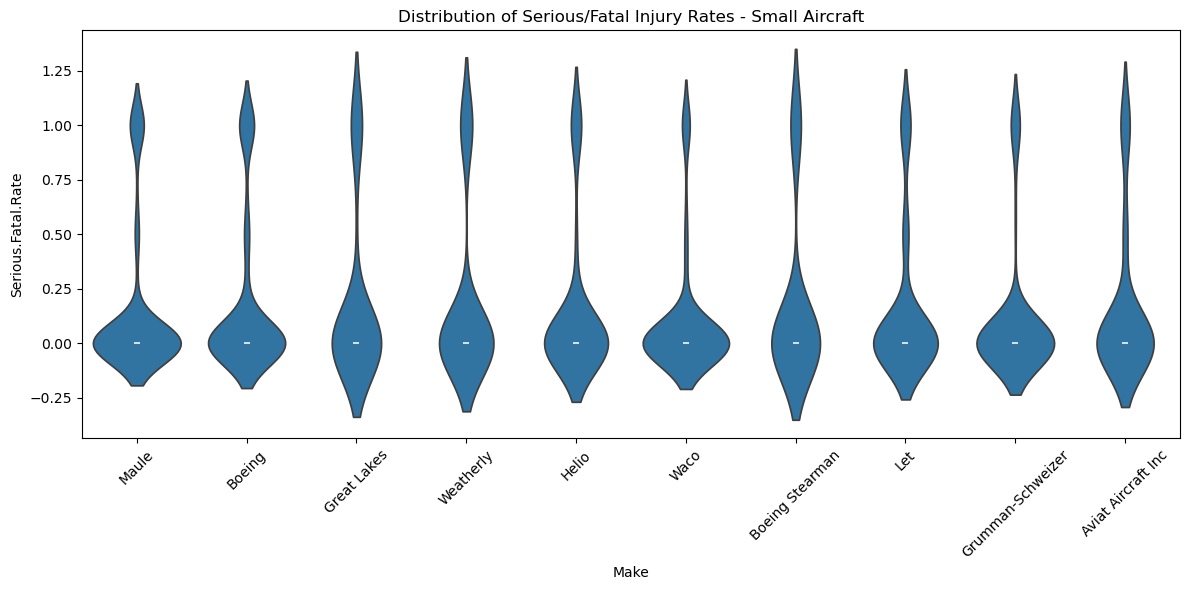

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 safest small-aircraft makes
top10_small = small_make_safety.head(10).index

small_plot = small_aircraft[
    small_aircraft["Make"].isin(top10_small)
]

plt.figure(figsize=(12,6))
sns.violinplot(
    data=small_plot,
    x="Make",
    y="Serious.Fatal.Rate"
)

plt.xticks(rotation=45)
plt.title("Distribution of Serious/Fatal Injury Rates - Small Aircraft")
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

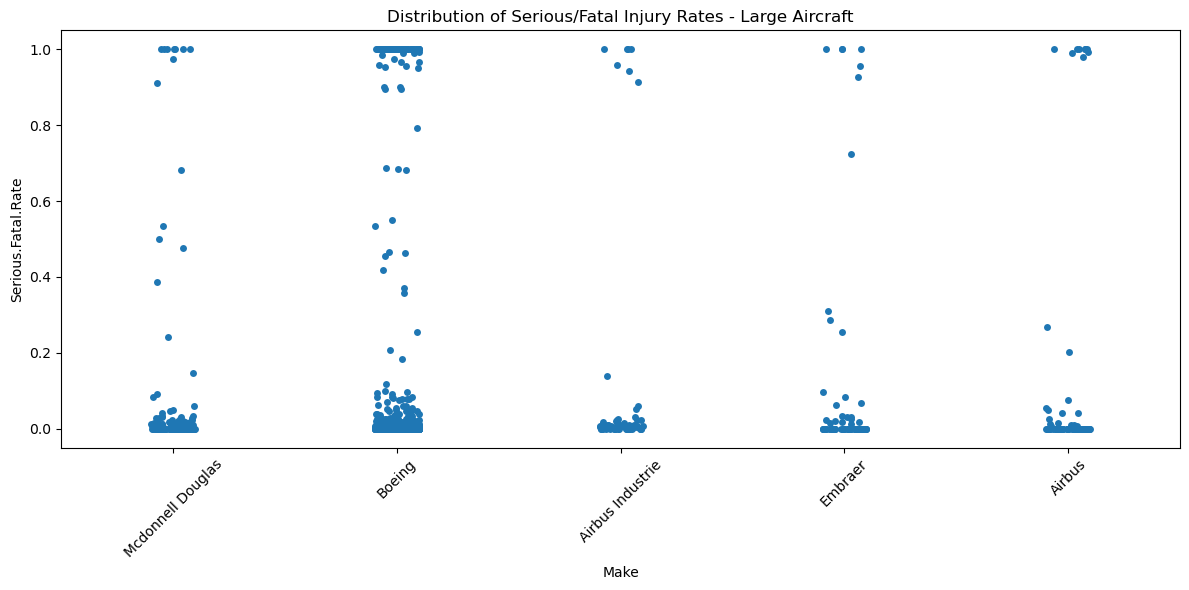

In [7]:
# Top 10 safest large-aircraft makes
top10_large = large_make_safety.head(10).index

large_plot = large_aircraft[
    large_aircraft["Make"].isin(top10_large)
]

plt.figure(figsize=(12,6))
sns.stripplot(
    data=large_plot,
    x="Make",
    y="Serious.Fatal.Rate",
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Serious/Fatal Injury Rates - Large Aircraft")
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [8]:
small_destroyed = (
    small_aircraft
    .groupby("Make")
    .agg(
        destruction_rate=("Destroyed", "mean"),
        accident_count=("Event.Id", "count")
    )
    .query("accident_count >= 50")
    .sort_values("destruction_rate")
    .head(15)
)

small_destroyed

,destruction_rate,accident_count
Make,,
Grumman Acft Eng Cor-Schweizer,0.017241,58
American Champion Aircraft,0.037736,53
Aviat Aircraft Inc,0.038961,77
Dehavilland,0.040816,98
Diamond Aircraft Ind Inc,0.055556,72
Robinson Helicopter,0.061135,229
Balloon Works,0.062069,145
Let,0.080882,136
Raven,0.082353,85


In [9]:
large_destroyed = (
    large_aircraft
    .groupby("Make")
    .agg(
        destruction_rate=("Destroyed", "mean"),
        accident_count=("Event.Id", "count")
    )
    .query("accident_count >= 50")
    .sort_values("destruction_rate")
    .head(15)
)

large_destroyed

,destruction_rate,accident_count
Make,,
Embraer,0.097222,72
Boeing,0.119777,718
Airbus Industrie,0.130435,69
Mcdonnell Douglas,0.132911,158
Airbus,0.133333,75


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
## Findings and Recommendations

### Findings

- Aircraft manufacturers differ considerably in their serious/fatal injury rates.
- Larger passenger aircraft generally have lower injury rates than smaller aircraft.
- Aircraft destruction rates also vary between manufacturers.
- Recommendations were limited to manufacturers with at least 50 recorded accidents to improve reliability.

### Recommendations

- Consider manufacturers that consistently show low serious/fatal injury rates and low aircraft destruction rates.
- Evaluate both injury outcomes and aircraft damage when making purchasing decisions.
- Continue monitoring accident trends as newer aircraft models become available.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

,mean_injury_rate,count
Aircraft.Type,,
Boeing 717-200,0.002024,10
Boeing 757-232,0.005404,16
Boeing 757-222,0.007309,12
Mcdonnell Douglas MD-88,0.007457,12
Mcdonnell Douglas DC-10-30,0.013243,11
Embraer EMB-145LR,0.016209,12
Mcdonnell Douglas MD-11,0.025407,13
Mcdonnell Douglas DC-10-10,0.052921,12
Boeing 747-400,0.057839,12


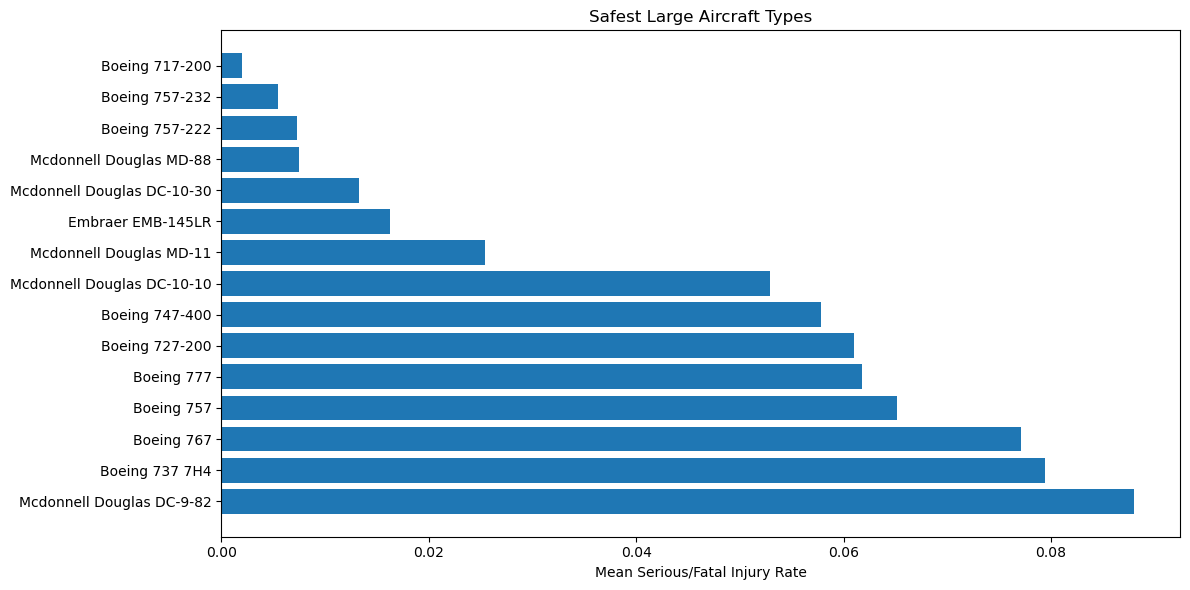

In [10]:
large_types = (
    large_aircraft.groupby("Aircraft.Type")
    .agg(
        mean_injury_rate=("Serious.Fatal.Rate", "mean"),
        count=("Event.Id", "count")
    )
    .query("count >= 10")
    .sort_values("mean_injury_rate")
    .head(15)
)

display(large_types)

plt.figure(figsize=(12,6))
plt.barh(
    large_types.index,
    large_types["mean_injury_rate"]
)
plt.xlabel("Mean Serious/Fatal Injury Rate")
plt.title("Safest Large Aircraft Types")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,mean_injury_rate,count
Aircraft.Type,,
Piper PA-18A 150,0.000000,12
Diamond Aircraft Ind Inc DA 20 C1,0.000000,11
Bell 47D-1,0.000000,11
Grumman G164B,0.000000,21
Howard Aircraft Corp. DGA-15P,0.000000,10
Cessna 180C,0.000000,15
Maule MX-7-235,0.029412,17
Burkhart Grob G103,0.033333,15
Hiller UH12E,0.035714,14


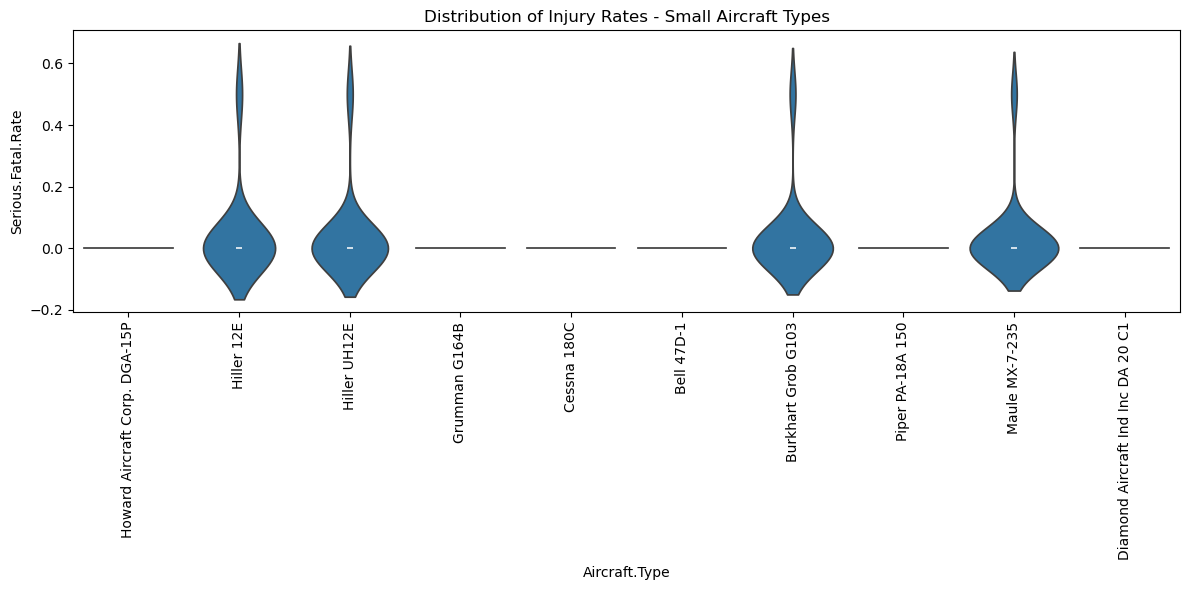

In [11]:
small_types = (
    small_aircraft.groupby("Aircraft.Type")
    .agg(
        mean_injury_rate=("Serious.Fatal.Rate", "mean"),
        count=("Event.Id", "count")
    )
    .query("count >= 10")
    .sort_values("mean_injury_rate")
    .head(10)
)

display(small_types)

plt.figure(figsize=(12,6))
sns.violinplot(
    data=small_aircraft[
        small_aircraft["Aircraft.Type"].isin(small_types.index)
    ],
    x="Aircraft.Type",
    y="Serious.Fatal.Rate"
)

plt.xticks(rotation=90)
plt.title("Distribution of Injury Rates - Small Aircraft Types")
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
## Discussion of Specific Airplane Types

### Findings

- Several aircraft types consistently show lower serious/fatal injury rates than others.
- Larger commercial aircraft generally demonstrate lower injury rates compared with smaller aircraft.
- Aircraft types with a larger number of recorded accidents provide more reliable comparisons.
- Results should be interpreted together with accident frequency and aircraft destruction rates.

### Recommendation

When selecting aircraft, prioritize models that consistently demonstrate:
- Low serious/fatal injury rates.
- Low aircraft destruction rates.
- A sufficient history of accident records to support reliable conclusions.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

In [ ]:
weather_summary = (
    df.groupby("Weather.Condition")
    .agg(
        mean_injury_rate=("Serious.Fatal.Rate", "mean"),
        destruction_rate=("Destroyed", "mean"),
        accidents=("Event.Id", "count")
    )
    .sort_values("mean_injury_rate", ascending=False)
)

display(weather_summary)

plt.figure(figsize=(8,5))
weather_summary["mean_injury_rate"].plot(kind="bar")
plt.ylabel("Mean Serious/Fatal Injury Rate")
plt.title("Effect of Weather Condition on Injury Rate")
plt.tight_layout()
plt.show()

In [ ]:
engine_summary = (
    df.groupby("Engine.Type")
    .agg(
        mean_injury_rate=("Serious.Fatal.Rate", "mean"),
        destruction_rate=("Destroyed", "mean"),
        accidents=("Event.Id", "count")
    )
    .sort_values("mean_injury_rate", ascending=False)
)

display(engine_summary)

plt.figure(figsize=(10,5))
engine_summary["mean_injury_rate"].plot(kind="bar")
plt.ylabel("Mean Serious/Fatal Injury Rate")
plt.title("Effect of Engine Type on Injury Rate")
plt.tight_layout()
plt.show()

## Exploring Other Variables

### Weather Condition

Accidents occurring in adverse weather generally showed higher serious/fatal injury rates than those occurring in good weather, indicating that weather conditions can significantly influence accident outcomes.

### Engine Type

Aircraft equipped with different engine types exhibited varying injury and aircraft destruction rates. These differences suggest that engine configuration may influence accident severity, although operational factors and aircraft design should also be considered.